# NYC Airbnb Data Workflow

**Name:** [Your Name]

**Dataset:** NYC Airbnb Open Data

## Project Overview

This project develops a reproducible data workflow using the NYC Airbnb Open Data dataset. The workflow covers data ingestion, cleaning, exploratory data analysis, visualization, and interpretation. The project establishes a reusable data foundation for future machine learning, deep learning, generative AI, and agentic AI projects.

### 1.  Setup

Import all the modules


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [30]:
import sys

print("Python executable:")
print(sys.executable)

Python executable:
c:\Users\pravi\Desktop\ai-master-capstone\project_01_data_workflow\.venv\Scripts\python.exe


### 2. Data Ingestion

The NYC Airbnb dataset is loaded from the project's data directory using Pandas. The original CSV file is treated as the raw source dataset and is not modified during the analysis.

In [31]:
df = pd.read_csv("../data/AB_NYC_2019.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [32]:
# Data dimensions

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 48,895
Columns: 16


In [33]:
# Inspect Columns
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [34]:
# inspect Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

### 3. Data Quality Assessment

Before cleaning the dataset, missing values, duplicate rows, data types, and review-related fields were examined. These checks help identify potential data-quality issues and determine which values can be safely cleaned without removing valid listings.

In [35]:
# Missing values

df.isna().sum().sort_values(ascending=False) 

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [36]:
# Duplicate rows

print(f"Duplicate rows: {df.duplicated().sum():,}")

Duplicate rows: 0


In [37]:
# diagnostics

review_missing_check = df[
    ["number_of_reviews", "last_review", "reviews_per_month"]
].isna()

print("Listings with zero reviews:",
      (df["number_of_reviews"] == 0).sum())

print("Missing last_review:",
      df["last_review"].isna().sum

      ())


print("Missing reviews_per_month:",
      df["reviews_per_month"].isna().sum())

print("\nListings with reviews but missing last_review:",
      ((df["number_of_reviews"] > 0) & df["last_review"].isna()).sum())

print("Listings with reviews but missing reviews_per_month:",
      ((df["number_of_reviews"] > 0) & df["reviews_per_month"].isna()).sum())

Listings with zero reviews: 10052
Missing last_review: 10052
Missing reviews_per_month: 10052

Listings with reviews but missing last_review: 0
Listings with reviews but missing reviews_per_month: 0


### 4. Data Cleaning

The cleaning process addresses missing values while preserving valid observations. Missing review activity is treated differently from missing descriptive information because the review fields have a meaningful relationship with listings that have received zero reviews.

In [38]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)



Project root: c:\Users\pravi\Desktop\ai-master-capstone\project_01_data_workflow


In [39]:
from src.data_cleaning import clean_review_fields, clean_text_fields

print("Cleaning functions imported successfully.")

Cleaning functions imported successfully.


In [40]:
df_clean = clean_review_fields(df)
df_clean = clean_text_fields(df_clean)

In [41]:
df_clean.isna().sum().sort_values(ascending=False)

last_review                       10052
id                                    0
host_id                               0
name                                  0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
host_name                             0
longitude                             0
room_type                             0
minimum_nights                        0
price                                 0
number_of_reviews                     0
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [42]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (48895, 16)
Cleaned shape: (48895, 16)


In [43]:
# Post-cleaning diagnostics

print("Missing values after cleaning:")
print(df_clean.isna().sum().sort_values(ascending=False))

Missing values after cleaning:
last_review                       10052
id                                    0
host_id                               0
name                                  0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
host_name                             0
longitude                             0
room_type                             0
minimum_nights                        0
price                                 0
number_of_reviews                     0
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [44]:
print("\nOriginal shape:", df.shape)
print("Cleaned shape:", df_clean.shape)


Original shape: (48895, 16)
Cleaned shape: (48895, 16)


In [45]:
# final check for text fields

print(
    "Unknown listings:",
    (df_clean["name"] == "Unknown Listing").sum()
)

print(
    "Unknown hosts:",
    (df_clean["host_name"] == "Unknown Host").sum()
)

Unknown listings: 16
Unknown hosts: 21


### 5. Exploratory Analysis

In [47]:


from src.eda import summarize_listings

eda_results = summarize_listings(df_clean)

print("Dataset shape:")
print(eda_results["shape"])

print("\nPrice statistics:")
display(eda_results["price_statistics"])

print("\nRoom type counts:")
display(eda_results["room_type_counts"])

print("\nListings by borough:")
display(eda_results["borough_counts"])

print("\nAverage price by room type:")
display(eda_results["average_price_by_room_type"])

print("\nAverage price by borough:")
display(eda_results["average_price_by_borough"])

Dataset shape:
(48895, 16)

Price statistics:


count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


Room type counts:


room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


Listings by borough:


neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


Average price by room type:


room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64


Average price by borough:


neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64

### 6. Visualizations

Three visualizations were created to examine the distribution of listing prices and differences associated with borough and room type. Extreme prices are limited in selected visualizations only to improve readability; the underlying cleaned dataset remains unchanged.

In [51]:
from src.visualizations import (
    plot_price_distribution,
    plot_average_price_by_borough,
    plot_price_by_room_type
)

#### Figure 1: Distribution of Airbnb Listing Prices

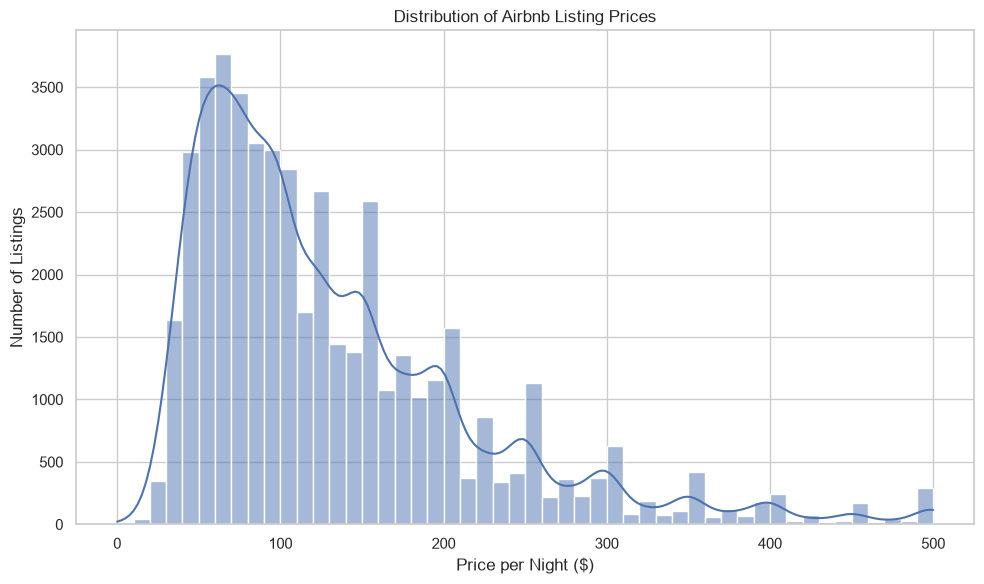

In [52]:
# Figure 1: Distribution of Airbnb Listing Prices

ax = plot_price_distribution(df_clean)

plt.savefig(
    "../outputs/figures/figure_1_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Airbnb listing prices are concentrated toward the lower end of the displayed range, while a smaller number of expensive listings create a right-skewed distribution. The visualization uses a $500 cutoff to make the main distribution easier to examine without allowing extreme prices to dominate the plot.

The $500 cutoff is used only for visualization; no listings were removed from the cleaned dataset.

#### Figure 2: Average Airbnb Price by Borough

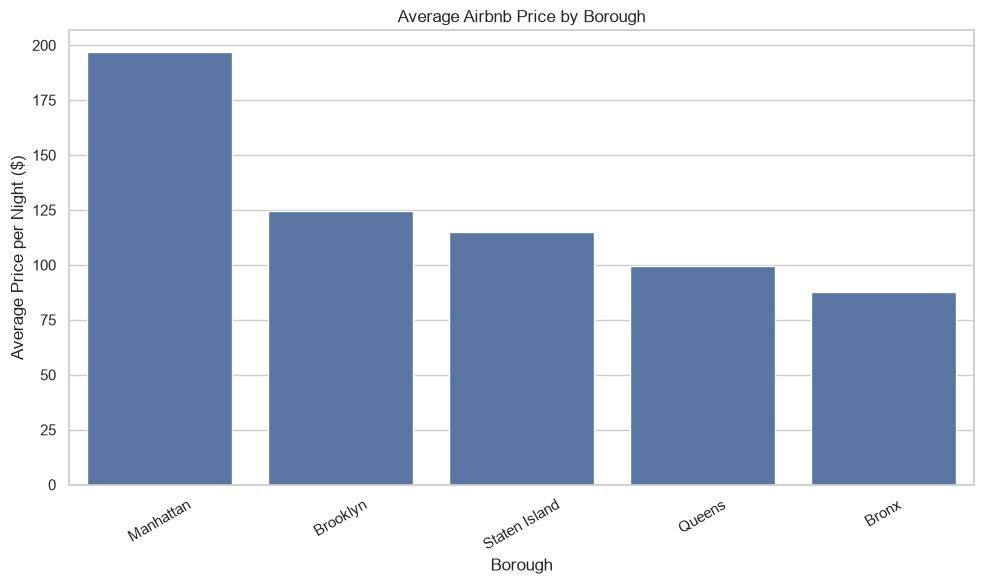

In [53]:
# Figure 2: Average Airbnb Price by Borough

ax = plot_average_price_by_borough(df_clean)

plt.savefig(
    "../outputs/figures/figure_2_average_price_borough.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The average listing price varies substantially across NYC boroughs. Manhattan has the highest average listing price at approximately $196.88 per night, followed by Brooklyn at approximately $124.38. The Bronx has the lowest average at approximately $87.50 per night. This suggests that geographic location is associated with differences in average Airbnb listing prices in this dataset.

#### Figure 3: Airbnb Prices by Room Type

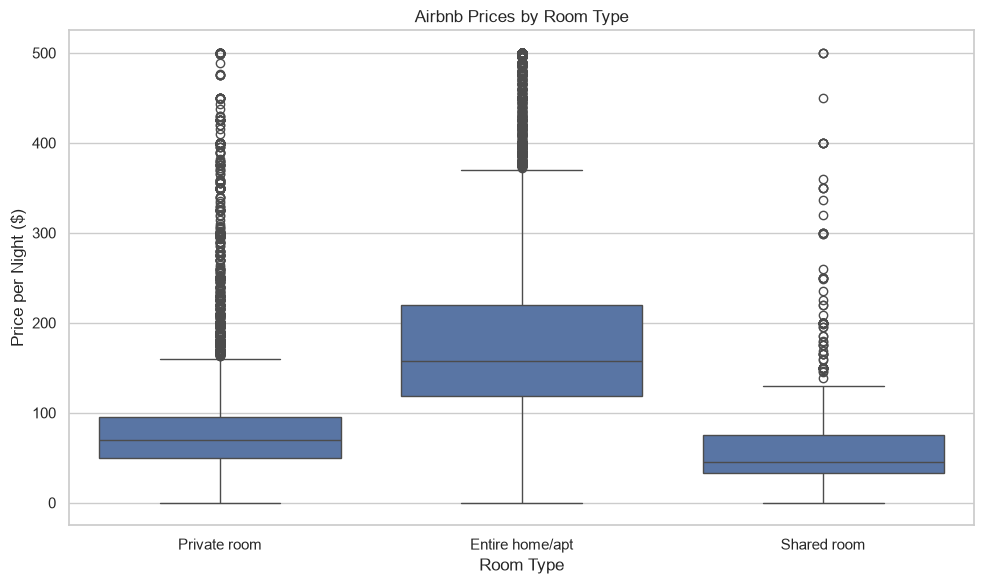

In [54]:
# Figure 3: Airbnb Prices by Room Type

ax = plot_price_by_room_type(df_clean)

plt.savefig(
    "../outputs/figures/figure_3_price_by_room_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Listing prices differ substantially by room type. Entire homes or apartments have the highest typical prices, while private rooms and shared rooms generally have lower prices. The boxplot also shows substantial variation within each room type, indicating that room type alone does not explain all differences in listing prices.

### 7. Summary and Interpretation

Summary

The analysis of the NYC Airbnb Open Data dataset identified clear differences in listing prices based on room type and borough. The dataset contains 48,895 listings across five NYC boroughs, with entire homes or apartments representing the largest room-type category. The exploratory analysis showed that entire homes or apartments had the highest average price at approximately $211.79 per night, compared with approximately $89.78 for private rooms and $70.13 for shared rooms.

Geographic differences were also evident. Manhattan had the highest average listing price at approximately $196.88 per night, while the Bronx had the lowest average at approximately $87.50. The price distribution was right-skewed, with most listings concentrated toward the lower end of the price range and a smaller number of substantially more expensive listings.

The analysis also showed that missing review information was associated with listings that had zero reviews. Because all 10,052 listings with zero reviews also had missing `last_review` and `reviews_per_month` values, the review-frequency values were treated as zero while the missing review dates were preserved. Missing listing and host names were replaced with descriptive placeholders without removing the affected listings.

### Key Insights

- Entire homes or apartments had substantially higher average prices than private or shared rooms.
- Manhattan had the highest average listing price among the five boroughs.
- Airbnb listing prices were strongly right-skewed, indicating that a relatively small number of expensive listings can influence the mean.
- Review-related missing values were systematically associated with listings that had received no reviews.
- The dataset contains substantial variation within both borough and room-type categories, suggesting that these variables alone do not explain all differences in listing prices.

### 8. Limitations and Responsible Data Practice

### Limitations

This dataset represents Airbnb listings from 2019 and therefore does not necessarily reflect current Airbnb prices, availability, or listing patterns in New York City. The analysis is descriptive and identifies associations between listing characteristics, borough, room type, and price; it does not establish that one variable causes differences in another.

The price variable also contains substantial variation, including listings with a price of $0 and listings with prices as high as $10,000 per night. Extreme values can influence summary statistics such as the mean, so the visualizations use a $500 price cutoff for readability. This cutoff was applied only when creating the visualizations and did not remove or modify observations in the cleaned dataset.

### Responsible Data Practice and Bias

Cleaning decisions can affect analytical results. Removing listings with missing names or host names would reduce the dataset and could unintentionally exclude particular types of listings. Instead, missing names were replaced with descriptive placeholders so that the observations could be retained.

The missing review fields required additional consideration. All 10,052 listings with zero reviews had missing `last_review` and `reviews_per_month` values, while no listings with reviews were missing those fields. Based on this pattern, missing `reviews_per_month` values were treated as zero for listings with no reviews, while missing `last_review` values were preserved because there is no meaningful review date for a listing that has never received a review.

The analysis also has potential representation bias because the dataset reflects Airbnb listings rather than the entire housing or lodging market. Listings that were present in the dataset may differ from properties that were not listed on Airbnb. Therefore, the findings should be interpreted as patterns within the available Airbnb listings rather than as a complete representation of New York City's housing market.

Future analysis could investigate unusual price values more closely, compare results using median prices in addition to means, and examine whether conclusions change when extreme observations are handled using alternative methods.

### 9. Reproducibility

This project is designed so that the analysis can be rerun using the same dataset, Python environment, project structure, and reusable source-code modules.

The raw NYC Airbnb dataset is stored in the `data` directory and is not modified during the analysis. Reusable data-cleaning, exploratory-analysis, and visualization functions are stored in the `src` directory:

- `src/data_cleaning.py` contains functions for cleaning review-related and text fields.
- `src/eda.py` contains functions for generating descriptive statistics and grouped summaries.
- `src/visualizations.py` contains functions for generating the project visualizations.

The analysis was developed and executed using a Python virtual environment. The installed Python dependencies are documented in `requirements.txt`.

To recreate the environment, activate the project virtual environment and install the required dependencies with:

```bash
pip install -r requirements.txt